# Previsão de Consumo em Sines — **LSTM**

Modelo recorrente (LSTM) para previsão horária do consumo elétrico em Sines (CP 7520).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)

DATA_PATH = os.path.join("data", "dataset_completo_sines.xlsx")
df = pd.read_excel(DATA_PATH)

# Converter datetime corretamente (sem unit='ns' — bug do código original)
df["Data/Hora"] = pd.to_datetime(df["Data/Hora"])
df = df.sort_values("Data/Hora").set_index("Data/Hora")

# Renomear coluna do código postal de Sines
if 7520 in df.columns:
    df = df.rename(columns={7520: "Sines_Consumo"})
df["Sines_Consumo"] = pd.to_numeric(df["Sines_Consumo"], errors="coerce")

print("Período:", df.index.min(), "->", df.index.max())
print("Shape:", df.shape)
df[["Sines_Consumo"]].describe().T

Período: 2023-01-01 00:00:00 -> 2023-09-30 22:00:00
Shape: (6558, 43)


,count,mean,std,min,25%,50%,75%,max
Sines_Consumo,6558.0,54981.672334,10329.416378,23468.336649,47416.44285,55568.033876,62928.197063,79577.898753


In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def safe_mape(y_true, y_pred, eps=1.0):
    """MAPE robusto: ignora valores próximos de zero para evitar divisões inválidas."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mask = np.abs(y_true) > eps
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(y_true, y_pred, nome="Modelo"):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape = safe_mape(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n=== {nome} ===")
    print(f"MAE : {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²  : {r2:.3f}")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

In [3]:
# Features comuns
cyclical_features = [
    "Hora_sin", "Hora_cos",
    "Dia_Semana_sin", "Dia_Semana_cos",
    "Mes_sin", "Mes_cos",
]
categorical_features = [
    "Fim_de_Semana",
    "Estacao_Inverno", "Estacao_Outono",
    "Estacao_Primavera", "Estacao_Verão",
]
# Lags do target (muito importantes!)
df["lag_1h"]  = df["Sines_Consumo"].shift(1)
df["lag_24h"] = df["Sines_Consumo"].shift(24)

features = cyclical_features + categorical_features + ["lag_1h", "lag_24h"]
features = [f for f in features if f in df.columns]   # tolera variações

df_model = df[features + ["Sines_Consumo"]].dropna()
print("Shape df_model:", df_model.shape)
df_model.head()

Shape df_model: (6534, 14)


,Hora_sin,Hora_cos,Dia_Semana_sin,Dia_Semana_cos,Mes_sin,Mes_cos,Fim_de_Semana,Estacao_Inverno,Estacao_Outono,Estacao_Primavera,Estacao_Verão,lag_1h,lag_24h,Sines_Consumo
Data/Hora,,,,,,,,,,,,,,
2023-01-02 00:00:00,0.000000,1.000000,0.0,1.0,0.0,1.0,0,1,0,0,0,47495.585620,45501.800240,46477.362890
2023-01-02 01:00:00,0.258819,0.965926,0.0,1.0,0.0,1.0,0,1,0,0,0,46477.362890,45170.849644,45524.832464
2023-01-02 02:00:00,0.500000,0.866025,0.0,1.0,0.0,1.0,0,1,0,0,0,45524.832464,44743.436723,45274.757473
2023-01-02 03:00:00,0.707107,0.707107,0.0,1.0,0.0,1.0,0,1,0,0,0,45274.757473,44559.972174,44902.097368
2023-01-02 04:00:00,0.866025,0.500000,0.0,1.0,0.0,1.0,0,1,0,0,0,44902.097368,44454.468574,44240.505902


In [4]:
n = len(df_model)
split_idx = int(n * 0.8)
split_ts  = df_model.index[split_idx]
print("Split em:", split_ts)

train_df = df_model.iloc[:split_idx]
test_df  = df_model.iloc[split_idx:]
print("Train:", train_df.shape, " | Test:", test_df.shape)

Split em: 2023-08-07 12:00:00
Train: (5227, 14)  | Test: (1307, 14)


In [5]:
from sklearn.preprocessing import MinMaxScaler

X_train_raw = train_df[features].values
y_train_raw = train_df["Sines_Consumo"].values
X_test_raw  = test_df[features].values
y_test_raw  = test_df["Sines_Consumo"].values

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_test_scaled  = scaler_X.transform(X_test_raw)
y_train_scaled = scaler_y.fit_transform(y_train_raw.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test_raw.reshape(-1, 1))

In [6]:
def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i, :])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

LOOKBACK = 48  # 2 dias de histórico

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, LOOKBACK)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test_scaled,  LOOKBACK)

print("X_train_seq:", X_train_seq.shape, " y_train_seq:", y_train_seq.shape)
print("X_test_seq :", X_test_seq.shape,  " y_test_seq :", y_test_seq.shape)

X_train_seq: (5179, 48, 13)  y_train_seq: (5179, 1)
X_test_seq : (1259, 48, 13)  y_test_seq : (1259, 1)


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    LSTM(96, return_sequences=True, kernel_regularizer=l2(1e-4),
         input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    BatchNormalization(),
    Dropout(0.2),

    LSTM(48, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1),
])

model.compile(optimizer=Adam(learning_rate=1e-3), loss=Huber(delta=1.0))
model.summary()

c:\Users\sofia\Downloads\Energia_Sines\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 96)         │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 96)         │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 48)             │        27,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,705 (276.19 KB)

 Trainable params: 70,417 (275.07 KB)

 Non-trainable params: 288 (1.12 KB)

In [8]:
early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-5, verbose=1)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=120,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=2,
)

Epoch 1/120
73/73 - 5s - 67ms/step - loss: 0.3716 - val_loss: 0.0624 - learning_rate: 0.0010
Epoch 2/120
73/73 - 2s - 27ms/step - loss: 0.2124 - val_loss: 0.0517 - learning_rate: 0.0010
Epoch 3/120
73/73 - 2s - 27ms/step - loss: 0.1482 - val_loss: 0.0631 - learning_rate: 0.0010
Epoch 4/120
73/73 - 2s - 26ms/step - loss: 0.1131 - val_loss: 0.0304 - learning_rate: 0.0010
Epoch 5/120
73/73 - 2s - 28ms/step - loss: 0.0840 - val_loss: 0.0325 - learning_rate: 0.0010
Epoch 6/120
73/73 - 2s - 27ms/step - loss: 0.0655 - val_loss: 0.0215 - learning_rate: 0.0010
Epoch 7/120
73/73 - 2s - 28ms/step - loss: 0.0513 - val_loss: 0.0388 - learning_rate: 0.0010
Epoch 8/120
73/73 - 2s - 28ms/step - loss: 0.0420 - val_loss: 0.0208 - learning_rate: 0.0010
Epoch 9/120
73/73 - 2s - 27ms/step - loss: 0.0348 - val_loss: 0.0209 - learning_rate: 0.0010
Epoch 10/120
73/73 - 2s - 25ms/step - loss: 0.0314 - val_loss: 0.0247 - learning_rate: 0.0010
Epoch 11/120
73/73 - 2s - 27ms/step - loss: 0.0263 - val_loss: 0.0161

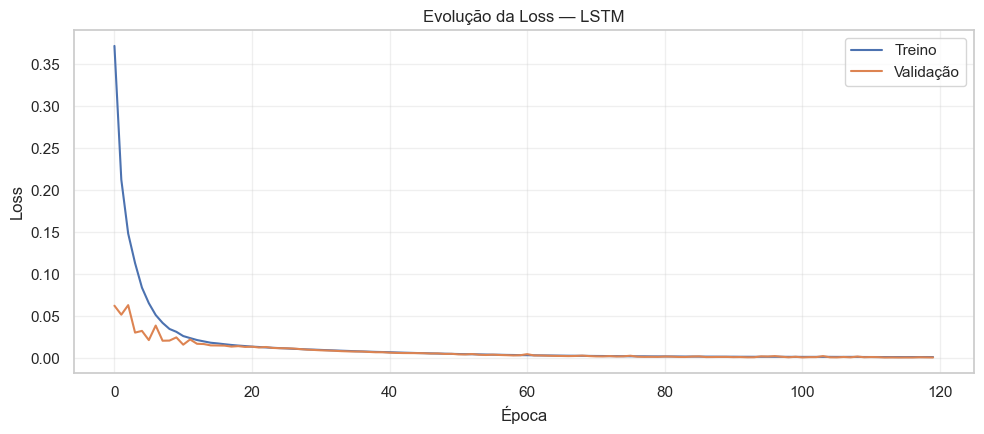

In [9]:
plt.figure(figsize=(10, 4.5))
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.title("Evolução da Loss — LSTM")
plt.xlabel("Época"); plt.ylabel("Loss"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [10]:
y_pred_scaled = model.predict(X_test_seq, verbose=0)
y_pred = scaler_y.inverse_transform(y_pred_scaled).ravel()
y_real = y_test_raw[LOOKBACK:]

metrics_lstm = evaluate(y_real, y_pred, nome="LSTM")


=== LSTM ===
MAE : 1695.656
RMSE: 2452.193
MAPE: 3.18%
R²  : 0.959


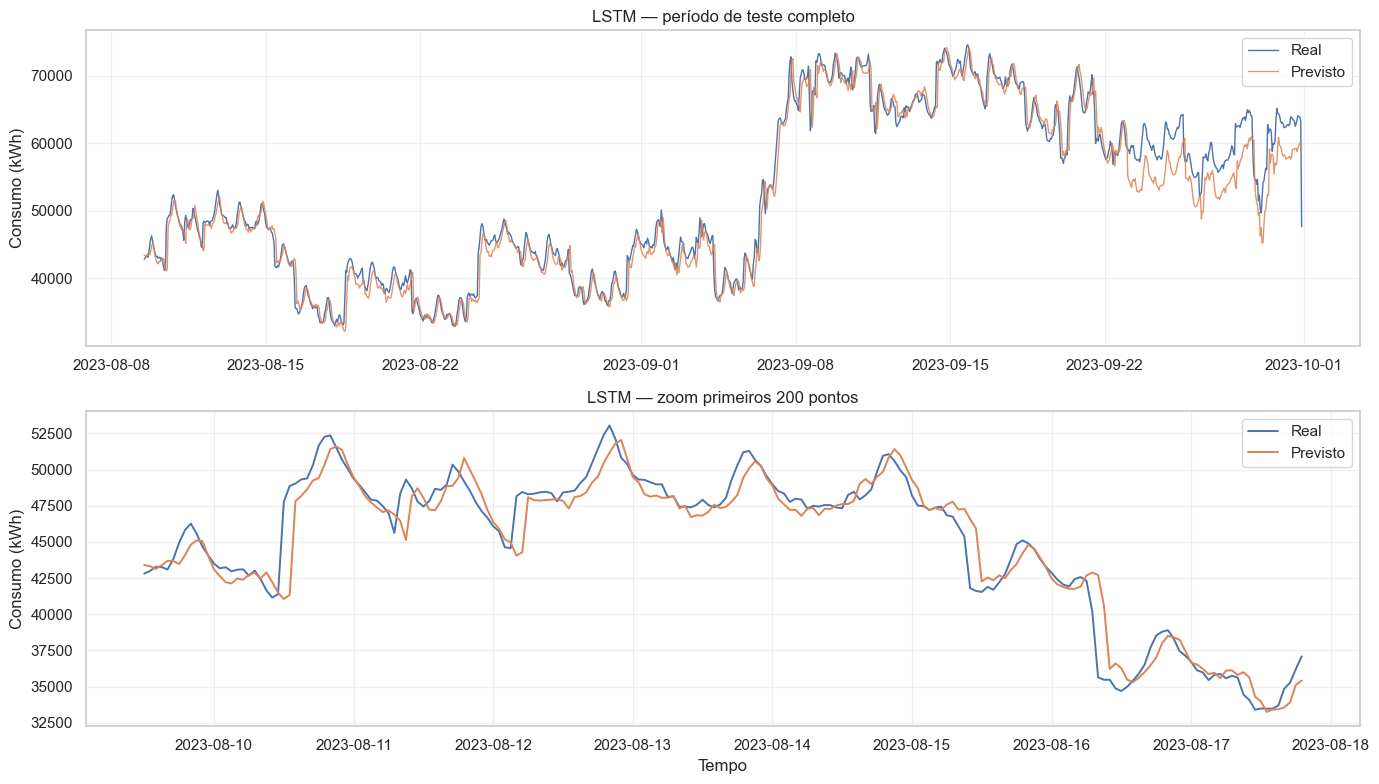

In [11]:
idx = test_df.index[LOOKBACK:]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(idx, y_real, label="Real", linewidth=1)
axes[0].plot(idx, y_pred, label="Previsto", linewidth=1, alpha=0.85)
axes[0].set_title("LSTM — período de teste completo")
axes[0].set_ylabel("Consumo (kWh)"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

zoom = 200
axes[1].plot(idx[:zoom], y_real[:zoom], label="Real", linewidth=1.4)
axes[1].plot(idx[:zoom], y_pred[:zoom], label="Previsto", linewidth=1.4)
axes[1].set_title(f"LSTM — zoom primeiros {zoom} pontos")
axes[1].set_xlabel("Tempo"); axes[1].set_ylabel("Consumo (kWh)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [12]:
# Guardar resultados para comparação final
os.makedirs("results", exist_ok=True)
pd.DataFrame([metrics_lstm], index=["LSTM"]).to_csv("results/metrics_lstm.csv")
print("Resultados guardados em results/metrics_lstm.csv")

Resultados guardados em results/metrics_lstm.csv
